In [27]:
%matplotlib inline
import numpy as np
import sqlite3
import matplotlib
import matplotlib.dates as mdates
import pandas as pd
import time
import os
from pathlib import Path
from dotenv import load_dotenv

db_path = "/home/jon/local/weatherwise/data/weather.sqlite" 

In [ ]:
def q_temp_humdity():
    conn = sqlite3.connect(db_path)
    query = """
        SELECT location, created_at, temperature, humidity 
        FROM chart 
        WHERE location = ? 
        ORDER BY created_at ASC
    """
    df = pd.read_sql_query(query, conn, params=(location_name,))
    conn.close()

    # 2. Process timestamps
    df["created_at"] = pd.to_datetime(df["created_at"])
    df.set_index("created_at", inplace=True)
    return df

In [65]:
def q_wind_direcction():
    conn = sqlite3.connect(db_path)
    query = """
        SELECT created_at, winddirection 
        FROM chart 
        WHERE location = ? 
        ORDER BY created_at ASC
    """
    df = pd.read_sql_query(query, conn, params=(location_name,))
    conn.close()

    # 2. Process timestamps
    df["created_at"] = pd.to_datetime(df["created_at"])
    df.set_index("created_at", inplace=True)
    return df

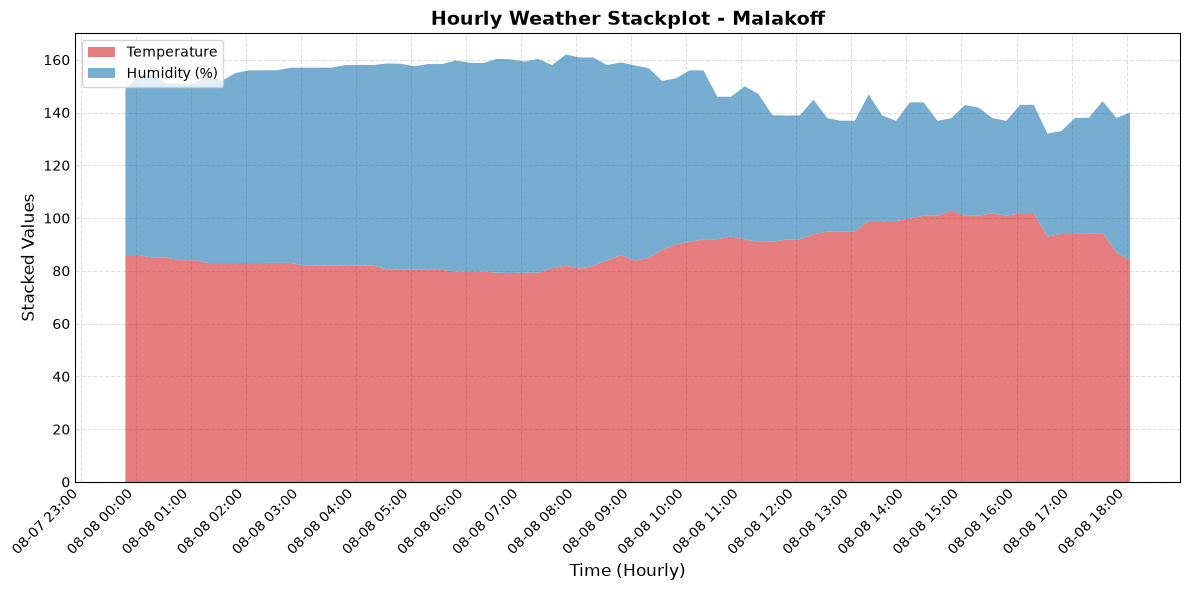

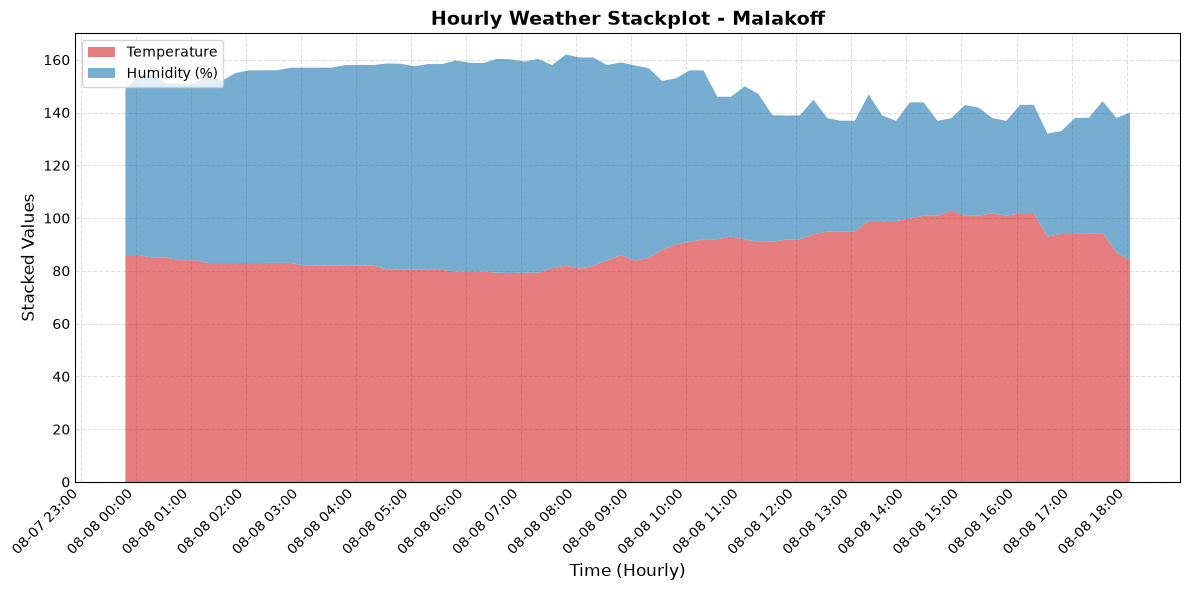

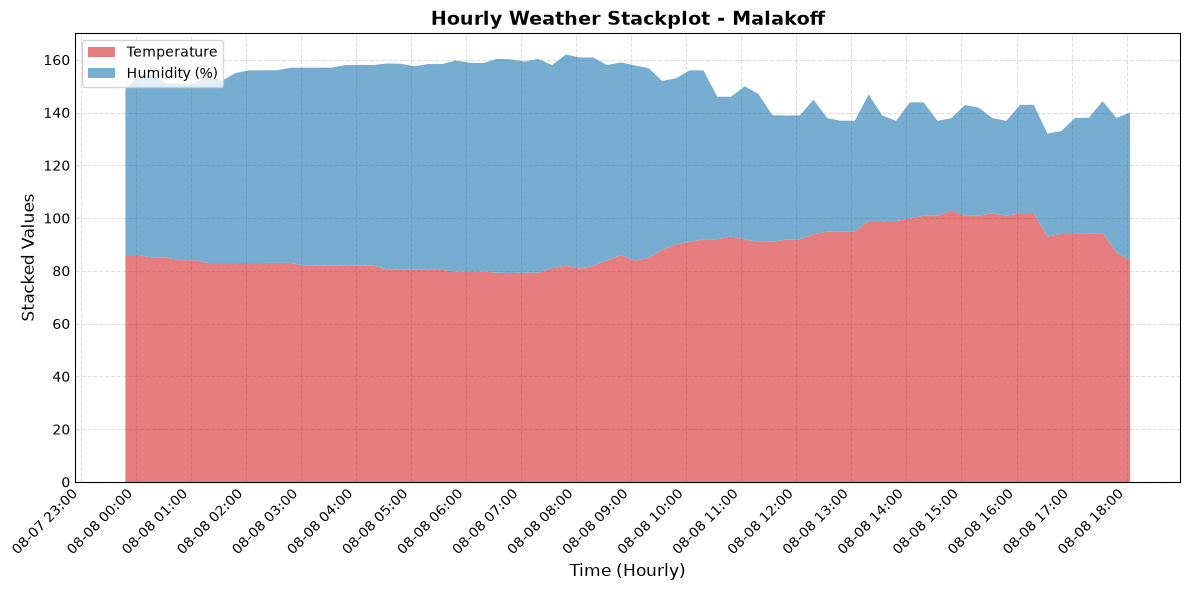

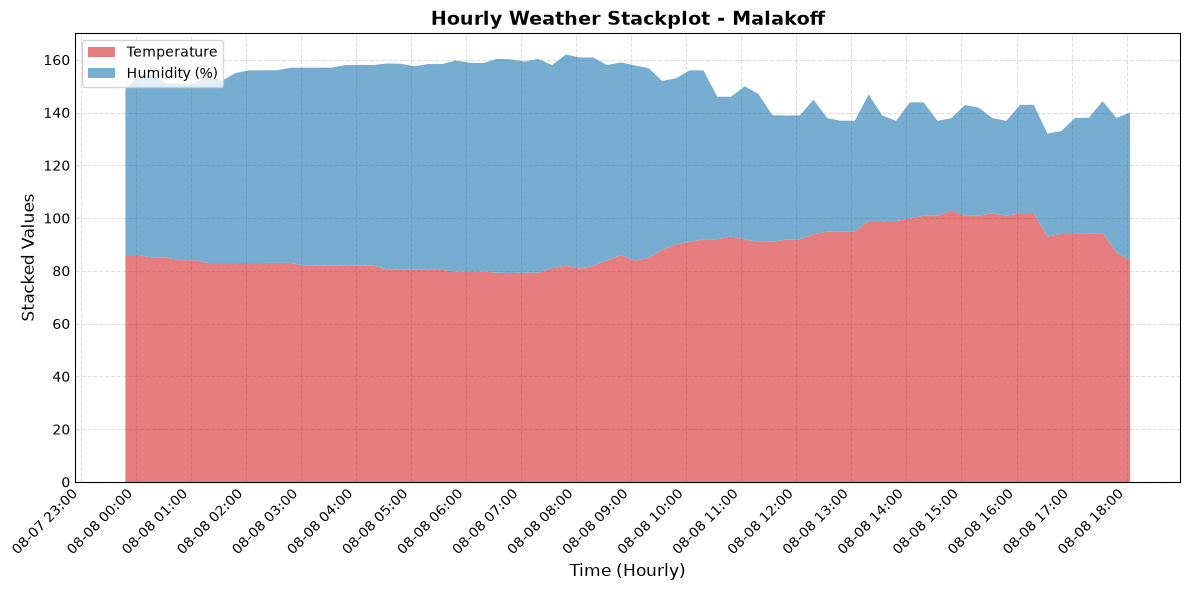

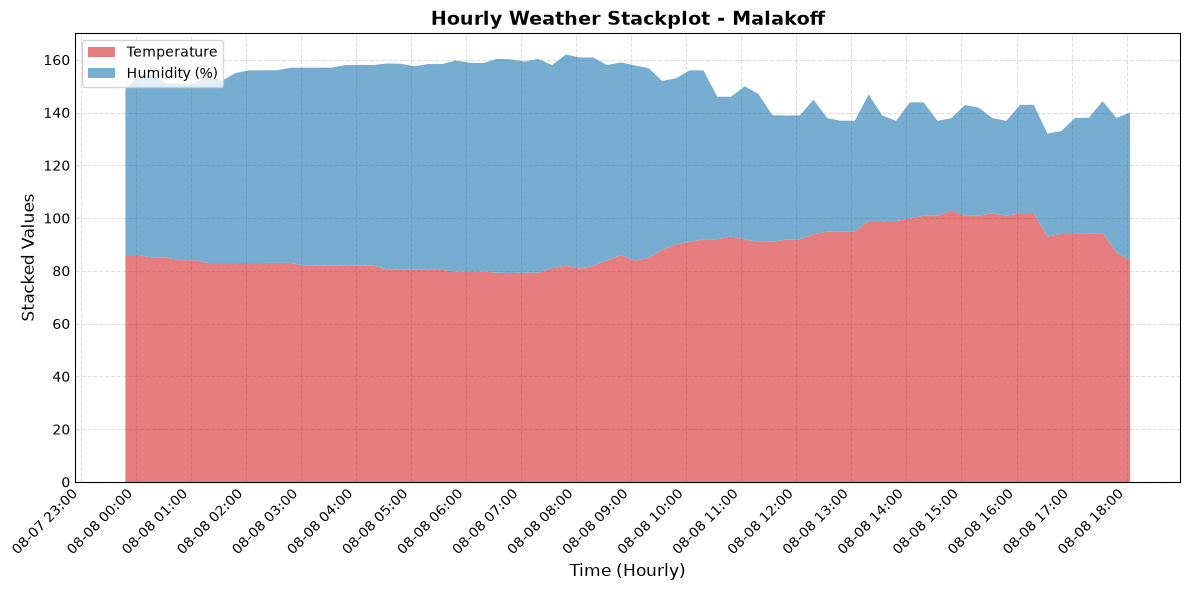

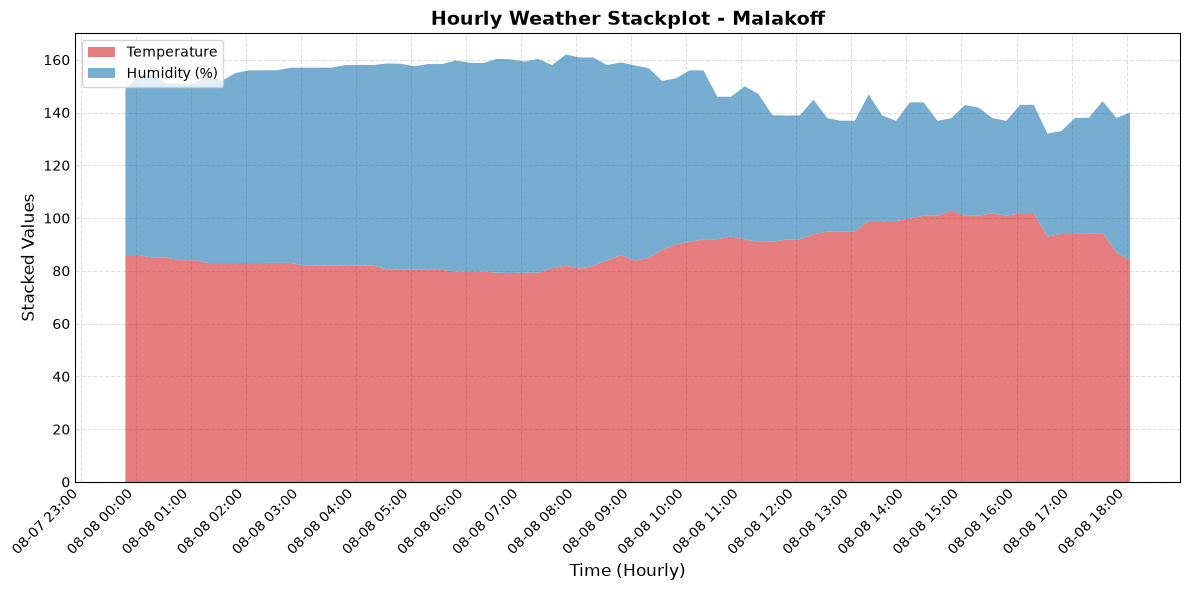

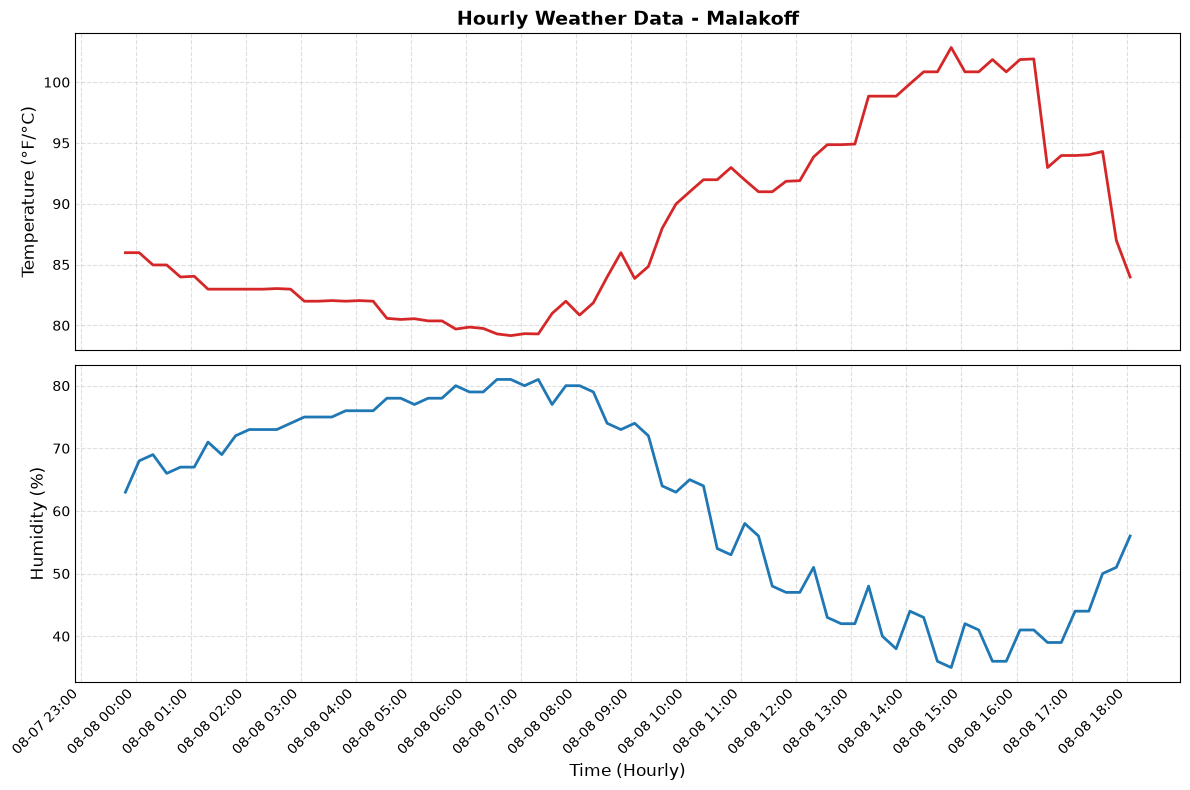

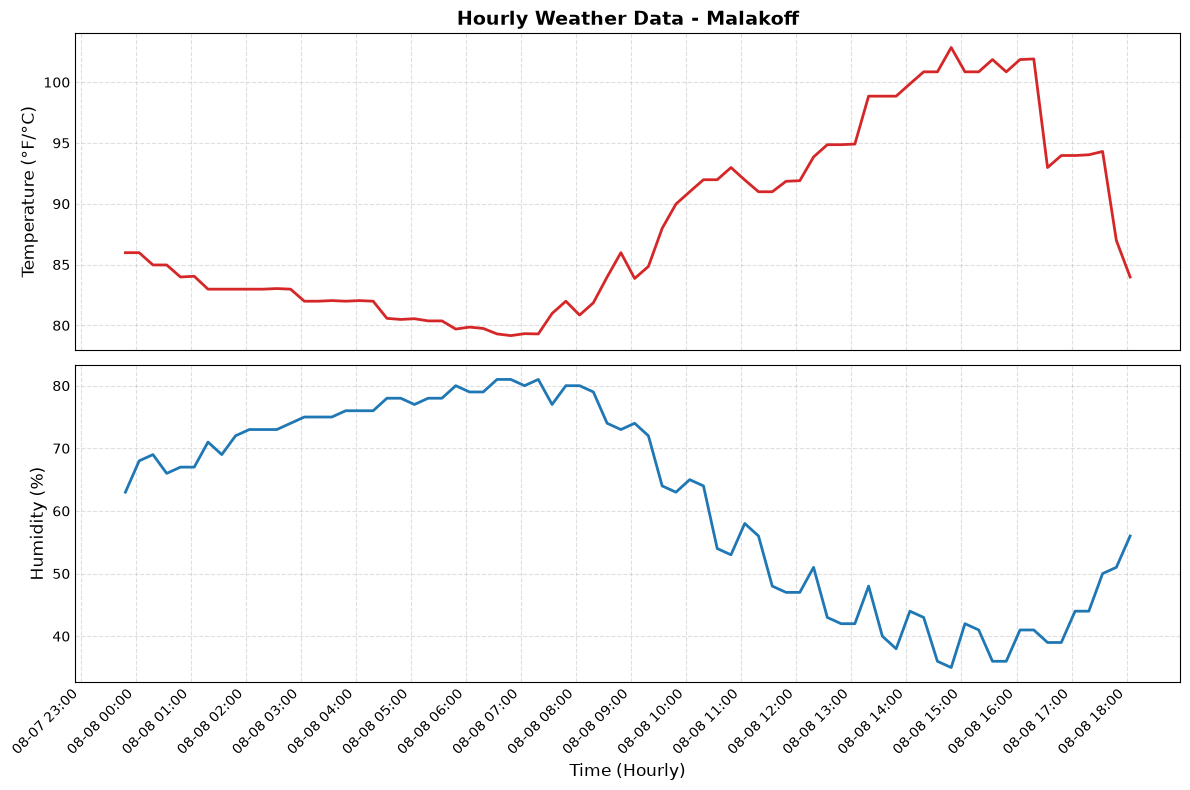

In [13]:

import os
import sqlite3
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load configuration and data
db_path = "/home/jon/local/weatherwise/data/weather.sqlite"
location_name = os.environ.get("CURRENT_LOCATION", "Default_Location")

conn = sqlite3.connect(db_path)
query = """
SELECT created_at, temperature, humidity 
FROM chart 
WHERE location = ? 
ORDER BY created_at ASC
"""
df = pd.read_sql_query(query, conn, params=(location_name,))
conn.close()

if df.empty:
  print(f"No data found for location: {location_name}")
else:
  # 2. Process timestamps
  df["created_at"] = pd.to_datetime(df["created_at"])
  df.set_index("created_at", inplace=True)

  # 3. Create subplots (temperature and humidity have different units)
  fig, (ax1, ax2) = plt.subplots(
      nrows=2, ncols=1, figsize=(12, 8), sharex=True
  )

  # 4. Plot Temperature
  ax1.plot(df.index, df["temperature"], color="tab:red", linewidth=2)
  ax1.set_ylabel("Temperature (°F/°C)", fontsize=12)
  ax1.grid(True, linestyle="--", alpha=0.4)
  ax1.set_title(
      f"Hourly Weather Data - {location_name}", fontsize=14, fontweight="bold"
  )

  # 5. Plot Humidity
  ax2.plot(df.index, df["humidity"], color="tab:blue", linewidth=2)
  ax2.set_ylabel("Humidity (%)", fontsize=12)
  ax2.set_xlabel("Time (Hourly)", fontsize=12)
  ax2.grid(True, linestyle="--", alpha=0.4)

  # 6. Format hourly X-axis on the bottom plot
  ax2.xaxis.set_major_locator(mdates.HourLocator(interval=1))
  ax2.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
  plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

  # 7. Save or show figure
  plt.tight_layout()
  plt.show()


/tmp/ipykernel_3957606/2174357559.py:2: MatplotlibDeprecationWarning: Passing the explode parameter of pie() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  ax.pie([1, 2, 3, 4], [1, 4, 2, 3])  # Plot some data on the Axes.


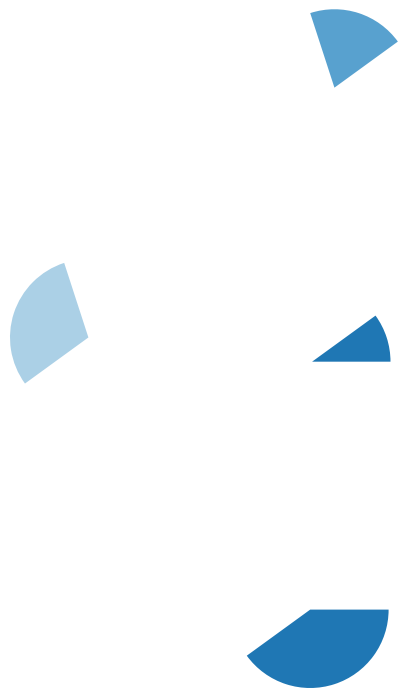

In [24]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.
ax.pie([1, 2, 3, 4], [1, 4, 2, 3])  # Plot some data on the Axes.
plt.show() 

<Figure size 200x200 with 0 Axes>

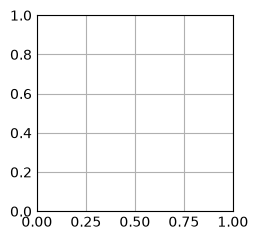

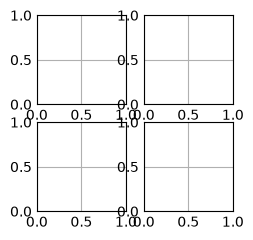

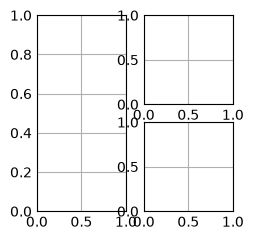

In [25]:
fig = plt.figure()             # an empty figure with no Axes
fig, ax = plt.subplots()       # a figure with a single Axes
fig, axs = plt.subplots(2, 2)  # a figure with a 2x2 grid of Axes
# a figure with one Axes on the left, and two on the right:
fig, axs = plt.subplot_mosaic([['left', 'right_top'],
                               ['left', 'right_bottom']])

In [ ]:
b = np.matrix([[1, 2], [3, 4]])
b_asarray = np.asarray(b)
b_asarray

Text(0, 0.5, 'entry b')

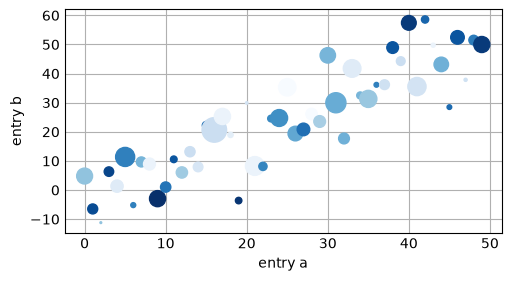

In [31]:
np.random.seed(19680801)  # seed the random number generator.
data = {'a': np.arange(50),
        'c': np.random.randint(0, 50, 50),
        'd': np.random.randn(50)}
data['b'] = data['a'] + 10 * np.random.randn(50)
data['d'] = np.abs(data['d']) * 100

fig, ax = plt.subplots(figsize=(5, 2.7), layout='constrained')
ax.scatter('a', 'b', c='c', s='d', data=data)
ax.set_xlabel('entry a')
ax.set_ylabel('entry b')

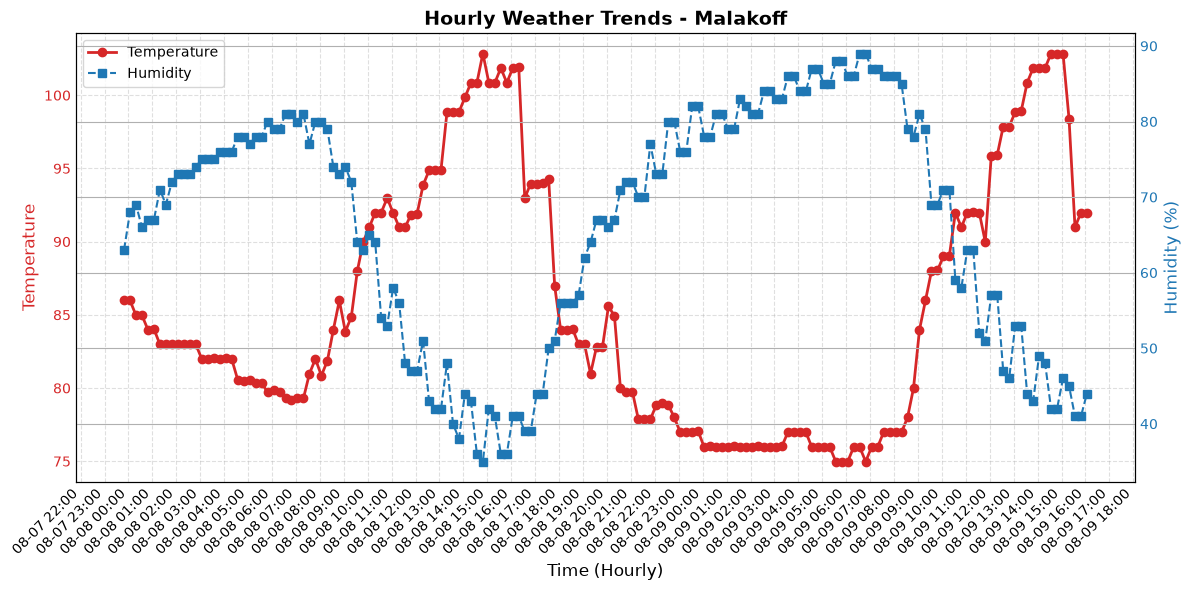

In [37]:
df = q()
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Temperature on the primary Y-axis (Left side)
color1 = "tab:red"
ax1.set_xlabel("Time (Hourly)", fontsize=12)
ax1.set_ylabel("Temperature", color=color1, fontsize=12)
line1 = ax1.plot(
  df.index,
  df["temperature"],
  marker="o",
  linestyle="-",
  color=color1,
  linewidth=2,
  label="Temperature",
  )
ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(True, linestyle="--", alpha=0.4)

# 5. Create a secondary Y-axis sharing the same X-axis (Right side)
ax2 = ax1.twinx()
color2 = "tab:blue"
ax2.set_ylabel("Humidity (%)", color=color2, fontsize=12)
line2 = ax2.plot(
  df.index,
  df["humidity"],
  marker="s",
  linestyle="--",
  color=color2,
  linewidth=1.5,
  label="Humidity",
  )
ax2.tick_params(axis="y", labelcolor=color2)

# 6. Format hourly X-axis
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")
# 7. Combine legends from both axes into one box
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

    # 8. Add title and save
plt.title(
  f"Hourly Weather Trends - {location_name}",
  fontsize=14,
  fontweight="bold",
  )
plt.tight_layout()

plt.show(fig)

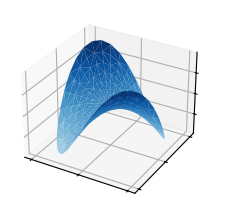

In [38]:
plt.style.use('_mpl-gallery')

n_radii = 8
n_angles = 36

# Make radii and angles spaces
radii = np.linspace(0.125, 1.0, n_radii)
angles = np.linspace(0, 2*np.pi, n_angles, endpoint=False)[..., np.newaxis]

# Convert polar (radii, angles) coords to cartesian (x, y) coords.
x = np.append(0, (radii*np.cos(angles)).flatten())
y = np.append(0, (radii*np.sin(angles)).flatten())
z = np.sin(-x*y)

# Plot
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
ax.plot_trisurf(x, y, z, vmin=z.min() * 2, cmap="Blues")

ax.set(xticklabels=[],
       yticklabels=[],
       zticklabels=[])

plt.show()

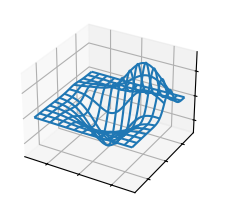

In [41]:
from mpl_toolkits.mplot3d import axes3d

plt.style.use('_mpl-gallery')

# Make data
X, Y, Z = axes3d.get_test_data(0.05)

# Plot
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_wireframe(X, Y, Z, rstride=10, cstride=10)

ax.set(xticklabels=[],
       yticklabels=[],
       zticklabels=[])

plt.show()

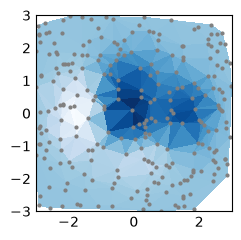

In [49]:
plt.style.use('_mpl-gallery-nogrid')

# make data:
np.random.seed(1)
x = np.random.uniform(-3, 3, 256)
y = np.random.uniform(-3, 3, 256)
z = (1 - x/2 + x**5 + y**3) * np.exp(-x**2 - y**2)

# plot:
fig, ax = plt.subplots()

ax.plot(x, y, 'o', markersize=2, color='grey')
ax.tripcolor(x, y, z)

ax.set(xlim=(-3, 3), ylim=(-3, 3))

plt.show()

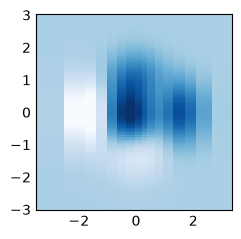

In [50]:
plt.style.use('_mpl-gallery-nogrid')

# make data with uneven sampling in x
x = [-3, -2, -1.6, -1.2, -.8, -.5, -.2, .1, .3, .5, .8, 1.1, 1.5, 1.9, 2.3, 3]
X, Y = np.meshgrid(x, np.linspace(-3, 3, 128))
Z = (1 - X/2 + X**5 + Y**3) * np.exp(-X**2 - Y**2)

# plot
fig, ax = plt.subplots()

ax.pcolormesh(X, Y, Z, vmin=-0.5, vmax=1.0)

plt.show()

Text(0, 0.5, 'entry b')

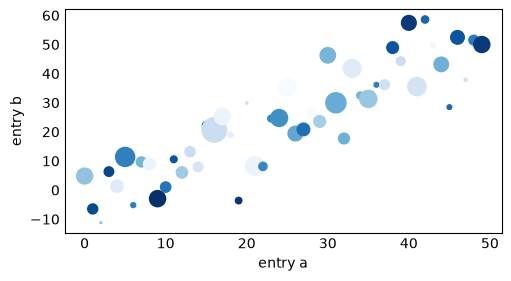

In [51]:
np.random.seed(19680801)  # seed the random number generator.
data = {'a': np.arange(50),
        'c': np.random.randint(0, 50, 50),
        'd': np.random.randn(50)}
data['b'] = data['a'] + 10 * np.random.randn(50)
data['d'] = np.abs(data['d']) * 100

fig, ax = plt.subplots(figsize=(5, 2.7), layout='constrained')
ax.scatter('a', 'b', c='c', s='d', data=data)
ax.set_xlabel('entry a')
ax.set_ylabel('entry b')

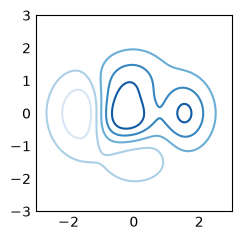

In [52]:
plt.style.use('_mpl-gallery-nogrid')

# make data
X, Y = np.meshgrid(np.linspace(-3, 3, 256), np.linspace(-3, 3, 256))
Z = (1 - X/2 + X**5 + Y**3) * np.exp(-X**2 - Y**2)
levels = np.linspace(np.min(Z), np.max(Z), 7)

# plot
fig, ax = plt.subplots()

ax.contour(X, Y, Z, levels=levels)

plt.show()

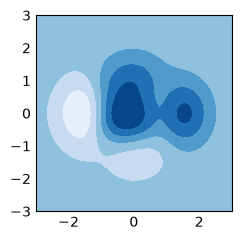

In [55]:
plt.style.use('_mpl-gallery-nogrid')

# make data
X, Y = np.meshgrid(np.linspace(-3, 3, 256), np.linspace(-3, 3, 256))
Z = (1 - X/2 + X**5 + Y**3) * np.exp(-X**2 - Y**2)
levels = np.linspace(Z.min(), Z.max(), 7)

# plot
fig, ax = plt.subplots()

ax.contourf(X, Y, Z, levels=levels)

plt.show()

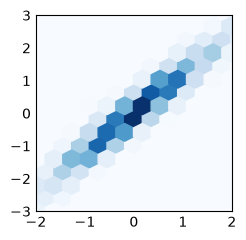

In [54]:
plt.style.use('_mpl-gallery-nogrid')

# make data: correlated + noise
np.random.seed(1)
x = np.random.randn(5000)
y = 1.2 * x + np.random.randn(5000) / 3

# plot:
fig, ax = plt.subplots()

ax.hexbin(x, y, gridsize=20)

ax.set(xlim=(-2, 2), ylim=(-3, 3))

plt.show()

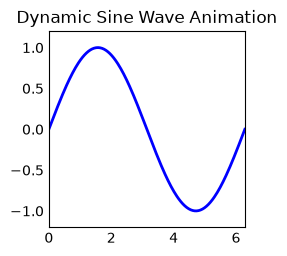

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# 1. Setup the figure, axis, and plot elements
fig, ax = plt.subplots()
x = np.linspace(0, 2 * np.pi, 200)
# Track the plot object with a trailing comma to unpack the list
line, = ax.plot(x, np.sin(x), color='blue', lw=2)

# Set persistent axis constraints
ax.set_xlim(0, 2 * np.pi)
ax.set_ylim(-1.2, 1.2)
ax.set_title("Dynamic Sine Wave Animation")

# 2. Define the animation update function
def update(frame):
    """Updates the data for each individual frame."""
    # Modify the y-data to shift the wave horizontally over time
    y = np.sin(x + frame / 10.0)
    line.set_ydata(y)
    return line,

# 3. Create the animation object
# frames: total frames to loop through
# interval: delay between frames in milliseconds
# blit: optimizes rendering by only updating parts that changed
ani = animation.FuncAnimation(fig, update, frames=100, interval=20, blit=True)

# 4. Display or save the visualization
plt.show()

# Optional: To save as a GIF (requires Pillow library)
ani.save('sine_wave.gif', writer='pillow', fps=30)


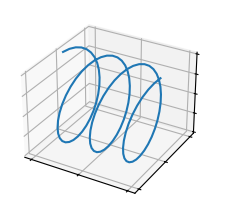

In [60]:
plt.style.use('_mpl-gallery')

# Make data
#n = 100
#xs = np.linspace(0, 1, n)
#ys = np.sin(xs * 6 * np.pi)
#zs = np.cos(xs * 6 * np.pi)


# Plot
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot(xs, ys, zs)

ax.set(xticklabels=[],
       yticklabels=[],
       zticklabels=[])

plt.show()

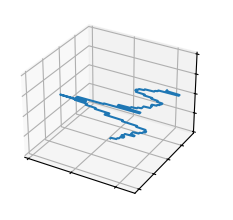

In [67]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# Make sure your q_wind_direcction() and db_path are defined above

# Get data from database
df = q_wind_direcction()

# Prepare 3D coordinates from DataFrame index and column
# Convert timestamps to numeric values for 3D plotting
ys = np.arange(len(df))
xs = df["winddirection"].values
zs = np.zeros_like(xs)  # Flat line or elevation layer on Z axis

# Apply style
plt.style.use("_mpl-gallery")

# Plot
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot(xs, ys, zs)

ax.set(xticklabels=[], yticklabels=[], zticklabels=[])

plt.show()
